In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset , random_split
from torch import manual_seed, nn, no_grad, optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

#torch.manual_seed(10101010) # because we randomly sort the data inside the data loader

# helper functions

In [2]:
def save_predictions_to_csv(predictions, csv_save_path):
    output_np = predictions.cpu().numpy()  # convert to numpy array 
    output_np = output_np.squeeze()  # remove channel dimension new shape: (N, 32, 64)
    unseen_labels_flat = output_np.reshape(output_np.shape[0], -1)  # flatten to shape (N, 32*64)
    
    # create a dataframe for your submission, this will have the format
    # id, 0, 1, 2, 3, ..., 2047
    # 0, value, value, value, value, ..., value
    # 1, value, value, value, value, ..., value
    # 2, value, value, value, value, ..., value
    # etc
    df_pred = pd.DataFrame(unseen_labels_flat, columns=[str(i) for i in range(unseen_labels_flat.shape[1])])
    df_pred.insert(0, 'id', range(unseen_labels_flat.shape[0]))

    # save your submission file
    df_pred.to_csv(csv_save_path, index=False)

def num_params(model):
    layers_store = []
    layer_idx = 0

    for param in model.parameters():
        if len(param.shape) > 1: # weights
            layers_store.append({"layer": layer_idx, "weight": param.numel(), "bias": 0})
            layer_idx += 1
        else: # bias
            # this bias is from the last layer, so add to that dict
            layers_store[-1]["bias"] = param.numel()
    # now we can loop over the list of dicts and print the info
    for layer in layers_store:
        print(f"Layer {layer['layer']}: {layer['weight']} weights, {layer['bias']} biases")
    total_params = sum(param.numel() for param in model.parameters())
    print(f"Total parameters: {total_params}")


# Loading and preprocesing the data

In [3]:
class TensorData(Dataset):
    def __init__(self, input_tensor, label_tensor):
        self.input = input_tensor
        self.labels = label_tensor

    def __len__(self):
        return self.input.size()[0]

    def __getitem__(self, index):
        return self.input[index], self.labels[index]

In [4]:
#Load Data numpy and pandas
hidden_test_inputs = "hidden_test_inputs.npy"
train_inputs = "train_inputs.npy"
train_labels = "train_labels.npy"
hidden_test_params = "hidden_test_params.csv"
sample_submission = "sample_submission.csv"
train_params = "train_params.csv"
   
hiden_inputs = np.load(hidden_test_inputs)
train_inputs = np.load(train_inputs)
train_labels = np.load(train_labels)
hiden_params = pd.read_csv(hidden_test_params)
sample_submission = pd.read_csv(sample_submission)
train_params = pd.read_csv(train_params)

In [5]:
train_params.head()

,id,delta_p,L,visc,delta_A
0,0,0.116960,22.151645,0.119214,7.109804
1,1,108.151111,39.206926,0.082552,1.900713
2,2,0.007357,3.169099,0.001266,4.621245
3,3,0.297560,17.772487,0.023173,3.433984
4,4,0.001844,13.915281,0.033173,10.534309


In [6]:
sample_submission.head()

,id,0,1,2,3,4,5,6,7,8,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0,0.698,0.536,0.310,0.814,0.685,0.163,0.911,0.823,0.950,...,0.753,0.769,0.659,0.766,0.846,0.614,0.089,0.488,0.078,0.407
1,1,0.407,0.066,0.349,0.111,0.808,0.948,0.072,0.955,0.522,...,0.394,0.131,0.672,0.729,0.575,0.207,0.504,0.312,0.427,0.645
2,2,0.745,0.232,0.405,0.269,0.199,0.783,0.909,0.370,0.751,...,0.639,0.338,0.907,0.587,0.085,0.450,0.756,0.794,0.495,0.895
3,3,0.268,0.411,0.898,0.896,0.686,0.859,0.089,0.865,0.321,...,0.176,0.606,0.337,0.585,0.316,0.087,0.223,0.188,0.428,0.658
4,4,0.264,0.012,0.519,0.606,0.963,0.589,0.471,0.573,0.928,...,0.364,0.853,0.756,0.610,0.364,0.210,0.776,0.486,0.225,0.195


In [7]:
def vizualize(np_matrix):
    plt.matshow(np_matrix)
    plt.show()

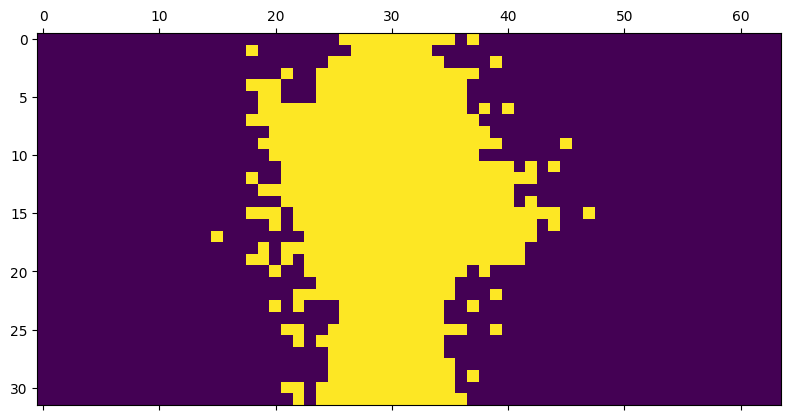

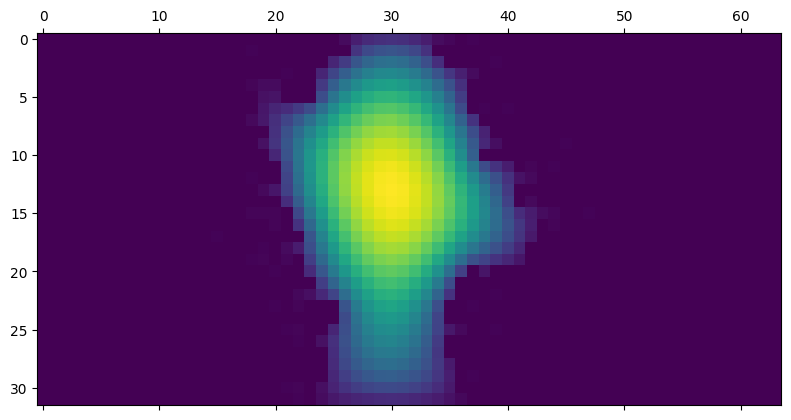

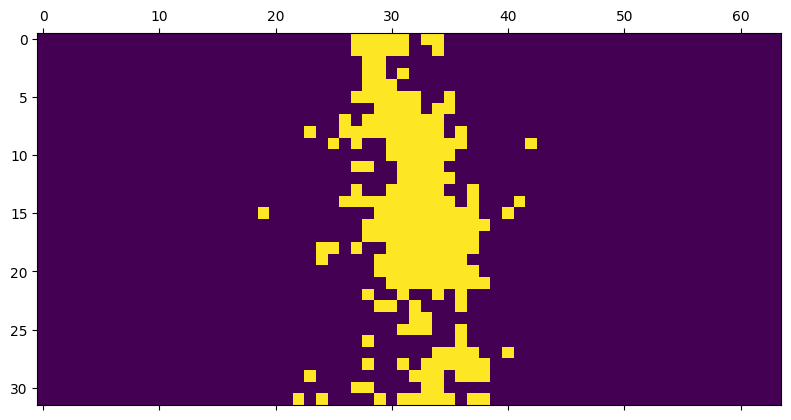

In [8]:
vizualize(train_inputs[9])
vizualize(train_labels[9])
vizualize(hiden_inputs[9])

In [9]:
#homogonize the data
def homogonize_data(params,inputs):
    delta_p = params['delta_p']
    L = params['L']
    visc = params['visc']
    delta_A = params['delta_A']
    homogonize = delta_p.mul(delta_A).div(L).div(visc)
    homogonize_np = homogonize.to_numpy().reshape((-1,1,1))
    return homogonize_np*inputs
train_inputs_hom = homogonize_data(train_params,train_inputs)
hiden_inputs_hom = homogonize_data(hiden_params,hiden_inputs)



If you want to use the gpu uncoment the .to('cuda')

In [10]:
image_tensor = torch.from_numpy( train_inputs_hom).type(torch.float32)#.to('cuda') 
lable_tensor = torch.from_numpy( train_labels).type(torch.float32)#.to('cuda')  
image_tensor = image_tensor.reshape(image_tensor.shape[0],1,image_tensor.shape[1],image_tensor.shape[2])
lable_tensor = lable_tensor.reshape(lable_tensor.shape[0],1,lable_tensor.shape[1],lable_tensor.shape[2])
Data_set = TensorData(image_tensor, lable_tensor)

kagel_tensor =  torch.from_numpy( train_inputs_hom).type(torch.float32)#.to('cuda') 
train_set, val_set = random_split(Data_set, [int(len(Data_set)*0.8), int(len(Data_set)*0.2)])






# Function declaration

In [49]:
import torch.nn as nn
import torch.nn.functional as F

# PyTorch models inherit from torch.nn.Module
class THE_MODEL(nn.Module):
    def __init__(self):
        super(THE_MODEL, self).__init__()
        self.conv1to8 = nn.Conv2d(in_channels=1,out_channels=8,kernel_size=3,stride=1,padding=1,dilation=1,groups=1,bias=False,padding_mode='zeros')
        self.conv8to16 = nn.Conv2d(in_channels=8,out_channels=16,kernel_size=3,stride=1,padding=1,dilation=1,groups=1,bias=False,padding_mode='zeros')
        self.conv16to32 = nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1,dilation=1,groups=1,bias=False,padding_mode='zeros')
        self.conv32to64 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1,dilation=1,groups=1,bias=False,padding_mode='zeros')
        self.conv64to128 = nn.Conv2d(in_channels=64,out_channels=128,kernel_size=1,stride=1,padding=0,dilation=1,groups=1,bias=False,padding_mode='zeros')
        self.conv128to64 = nn.Conv2d(in_channels=128,out_channels=64,kernel_size=1,stride=1,padding=0,dilation=1,groups=1,bias=False,padding_mode='zeros')
        #self.conv256to512 = nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3,stride=1,padding=0,dilation=1,groups=1,bias=False,padding_mode='zeros')
        #self.conv512to256 = nn.Conv2d(in_channels=512,out_channels=256,kernel_size=3,stride=1,padding=0,dilation=1,groups=1,bias=False,padding_mode='zeros')
        #self.conv512to128 = nn.Conv2d(in_channels=512,out_channels=128,kernel_size=3,stride=1,padding=0,dilation=1,groups=1,bias=False,padding_mode='zeros')
        #self.conv128to64 = nn.Conv2d(in_channels=128,out_channels=64,kernel_size=3,stride=1,padding=0,dilation=1,groups=1,bias=False,padding_mode='zeros')
        self.conv128to32 = nn.Conv2d(in_channels=128,out_channels=32,kernel_size=3,stride=1,padding=1,dilation=1,groups=1,bias=False,padding_mode='zeros')
        self.conv32to16 = nn.Conv2d(in_channels=32,out_channels=16,kernel_size=3,stride=1,padding=1,dilation=1,groups=1,bias=False,padding_mode='zeros')
        self.conv32to8 = nn.Conv2d(in_channels=32,out_channels=8,kernel_size=3,stride=1,padding=1,dilation=1,groups=1,bias=False,padding_mode='zeros')
        self.conv8to1 = nn.Conv2d(in_channels=8,out_channels=1,kernel_size=3,stride=1,padding=1,dilation=1,groups=1,bias=False,padding_mode='zeros')

        self.pool = nn.MaxPool2d(kernel_size= 2, stride=2, padding=0, dilation=1, return_indices=False, ceil_mode=False)
        self.ups = nn.Upsample(scale_factor=2, mode='nearest')
    
    def forward(self,x):

        L1 = F.relu(self.conv8to16(F.relu(self.conv1to8(x))))
        
        L2 = F.relu(self.conv32to64(F.relu(self.conv16to32(self.pool(L1)))))
      #  print(L2)
        L3 = F.relu(self.conv128to64(F.relu(self.conv64to128(self.pool(L2)))))
#        L4 = F.relu(self.conv512to256(F.relu(self.conv256to512(self.pool(L3)))))

#        O3 = F.relu(self.conv124to64(F.relu(self.conv512to124( torch.cat(L3,self.ups(L4))))))
        O2 = F.relu(self.conv32to16(F.relu(self.conv128to32( torch.cat((L2,self.ups(L3)),dim = 1)))))
        O1 = F.relu(self.conv8to1(F.relu(self.conv32to8( torch.cat((L1,self.ups(O2)),dim = 1)))))
        return O1
model = THE_MODEL()

In [12]:
print('The model:')
print(model)

print('\n\nModel params:')
for param in model.parameters():
    print(param)

The model:
THE_MODEL(
  (conv1to8): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv8to16): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv16to32): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv32to64): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv64to128): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (conv128to64): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (conv128to32): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv32to16): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv32to8): Conv2d(32, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (conv8to1): Conv2d(8, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

In [13]:
def train_1_epoch(training_loader,loss_fn,optimizer):
    epoch_loss_sum = 0
    for i, data in enumerate(training_loader):
        inputs, labels = data
        # Reset optimizer gradients.
        optimizer.zero_grad()
        # Predict the output
        y_pred = model(inputs)
        # Compute the loss
        loss = loss_fn(y_pred, labels)
        epoch_loss_sum += loss.item()
        # Compute gradients according to newly computed loss.
        loss.backward()
        # Update the model parameters.
        optimizer.step()
    return epoch_loss_sum

In [23]:
def train_model(
train_data,
test_data,
model,
loss_fn,
epochs:int,
lr:float,
batch_size:int,
print_every:int,
):
    
    loss_dict = {"train": [], "test": [], "test_acc": []}
    best_model = 0
    best_test = 500000
    # Initialize optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)
    dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    testloader = DataLoader(test_data, batch_size=len(test_data))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.1,patience=10)    
    # Print header.
    print(f"Epoch    Train loss      Test loss       Test accuracy")
    for epoch in range(epochs):
        
        train_loss = train_1_epoch(dataloader,loss_fn,optimizer)
        loss_dict["train"].append(train_loss / len(train_data))

        with no_grad():
            for i, test in enumerate(testloader):
                test_inputs, test_data = test
                test_pred = model(test_inputs)
                test_accuracy = loss_fn(test_pred , test_data )/len(test_data)
                loss_dict["test"].append(test_accuracy.item())
        if (epoch + 1) % print_every == 0:
            print(
                f"{epoch+1: <7}  {loss_dict['train'][-1]: <14.6e}  {loss_dict['test'][-1]: <13.6e}"
            )
        if  loss_dict["test"][-1] < best_test:
            best_model = torch.save(model.state_dict(),"model.param")
            best_test = loss_dict["test"][-1]
            
    return loss_dict

In [15]:
def plot_loss(loss , labels:bool):
    epochs = np.arange(len(loss['train']))
    plt.plot(epochs, loss['train'], label="Train Loss")
    plt.plot(epochs, loss['test'], label="Test Loss")

    plt.xlabel("Epoch")
    if labels:
        plt.ylabel("BCE Loss")
    else:
        plt.ylabel("MSE Loss")
    plt.yscale("log")
    plt.xscale("log")
    plt.legend()

    plt.show()

In [16]:

    
def plot_accuracies(test_dict, expected_value_random_guess = 0.5):
    test_acc = test_dict["test_acc"]
    plt.plot(test_acc, label="test accuracy", marker=".", lw=2)
    plt.axhline(expected_value_random_guess, color='cyan', linestyle='--', label='Random Guess accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [17]:
def plot_result_MSE(data_dict, model):
    with torch.no_grad():
        loss = loss_fn(y_pred, data_dict["y"])

        # print(loss.item())
        loss_amount = loss.item()
        print(f"Final MSE Loss: {loss_amount}")

        # plt.plot(y_pred.cpu().numpy(), data_dict["y_test"].cpu().numpy(), "o")
        plt.hist2d(
            data_dict["y"].cpu().numpy().flatten(),
            y_pred.cpu().numpy().flatten(),
            bins=50,
        )
        plt.xlabel("Predicted")
        plt.ylabel("Ground truth")
        plt.colorbar()
        plt.title(f"(Final MSE Loss: {loss_amount:.4f})")

        # plot line x = y
        x = [0, 12]
        plt.plot(x, x, "r")

        plt.show()
    return y_pred.cpu().numpy().flatten().T



In [18]:
def plot_result_MAPE(data_dict, model):
    with torch.no_grad():
        y_pred = model(data_dict["x"])
        print(y_pred)
        print(data_dict["y"])
        loss = MAPE_loss(y_pred, data_dict["y"])
        print(loss)
        

        
        # print(loss.item())
        loss_amount = loss.item()
        print(f"Final MSE Loss: {loss_amount}")

        # plt.plot(y_pred.cpu().numpy(), data_dict["y_test"].cpu().numpy(), "o")
        plt.hist2d(
            data_dict["y"].cpu().numpy().flatten(),
            y_pred.cpu().numpy().flatten(),
            bins=50,
        )
        plt.xlabel("Predicted")
        plt.ylabel("Ground truth")
        plt.colorbar()
        plt.title(f"(Final MSE Loss: {loss_amount:.4f})")

        # plot line x = y
        x = [0, 12]
        plt.plot(x, x, "r")

        plt.show()
    return y_pred.cpu().numpy().flatten().T



In [53]:
def MAE(prediction, truth):
    return torch.mean(torch.abs((prediction - truth) / (truth+1e-15)))

# Training of T1

In [54]:
epochs = 10
print_every = 1
width = 40
lr = 5e-4
batch_size = 75


#model = torch.compile(model)
loss_fn = MAE
models__IPFCE, loss_dict__IPFCE = train_model(train_set, val_set,model,loss_fn,epochs,lr,batch_size,print_every)



Epoch    Train loss      Test loss       Test accuracy
1        4.626505e+00    6.091960e-04 
2        2.451519e-03    6.091960e-04 
3        2.451519e-03    6.091960e-04 
4        2.451519e-03    6.091960e-04 
5        2.451519e-03    6.091960e-04 


KeyboardInterrupt: 

In [ ]:
plot_accuracies(loss_dict__IPFCE,0.5)
plot_loss(loss_dict__IPFCE,True)

# Training of T2

In [ ]:
#Mape = 0.34 -> width = 140; epochs = 500, lr = 0.1e-3

width = 120
model = make_model_MAEBAPF(width)
epochs = 10
print_every = epochs/100

lr = 1e-4
batch_size = 100
labels = False
#loss_fn = nn.L1Loss() # different loss function dont know which one to use

loss_fn = nn.MSELoss() # same loss function as in assignment 1

print(tensor_nd_train['x'].shape)
print(tensor_nd_train['y'].shape)
print(tensor_nd_train['L'].shape)
models_MAEBAPF, loss_dict_MAEBAPF = train_model(tensor_nd_train,tensor_nd_test,labels,model,loss_fn,epochs,lr,batch_size,print_every)

In [ ]:
plot_result_MAPE(tensor_nd_test, models_MAEBAPF)
plot_loss(loss_dict_MAEBAPF,False)

# submision

In [ ]:
prediction = model(tensor_nd_bench['x']).to('cpu')

submision_numpy = prediction.detach().numpy()

scale = data_pd_bench_sorted[8].to_numpy().reshape((-1,1))


if not labels:
    submision_numpy = np.multiply(submision_numpy , scale)#multiply by the length to turn it form dimensionles back to Area
    submision_numpy = np.multiply(submision_numpy , scale)
    
    submission_df = pd.DataFrame(submision_numpy)
    submission = pd.DataFrame({
        "id": range(prediction.shape[0]),
        "prediction": submision_numpy.flatten()})
    print(submission)
    submission.to_csv("predictions.csv", index=False)
    

else: 
    
    submission_df = pd.DataFrame(submision_numpy)
    submission = pd.DataFrame({
        "id": range(prediction.shape[0]),
        "prediction": submision_numpy.flatten()>0.5})
    print(submission)
submission.to_csv("predictions.csv", index=False)



# numpy Functions

In [ ]:
data_nh = data_nh.reset_index(drop=True)
data_nh_train_pd = data_nh.sample(frac = 0.8 , random_state=1111,ignore_index=True)
data_nh_train_pd = data_nh_train_pd[['0','1','2','3','4','5','6','7','8','area']]


data_nh_test_pd = data_nh.drop(data_nh_train_pd.index).reset_index(drop=True)
data_nh_test_pd = data_nh_test_pd[['0','1','2','3','4','5','6','7','8','area']]

z = data_nh_train_pd['area']


data_nh_test = data_nh_test_pd.to_numpy()
data_nh_train = data_nh_train_pd.to_numpy()
print(data_nh_train)
print(data_nh_test)

In [ ]:
#The different way to initilialize the weights
def init_weights_2(input_dim, output_dim, sigma=0.1):
    return np.random.normal(0.0, sigma, (input_dim, output_dim))

In [ ]:
# Predict using a trained set of model weights for a 3 hidden layer network
def predict_depth3(input, weights):
    [w1, w2, w3, w4] = weights
    return relu(relu(relu(input @ w1) @ w2) @ w3) @ w4

In [ ]:
# Loss functions
def msre(input, target):
    return np.square((target - input) / target).mean()

In [ ]:
# Activation functions

def relu(input):
    return np.maximum(0, input)

In [ ]:
#D1H Depth 3 Mini Batch

# Function to train a simple 2-N-1 model.
# NOTE: This function expects numpy matrices for the train and test data.
#       If your train and test data is stored in pandas dataframes you 
#       can convert using the `.to_numpy()` function.

def train_model_dh_depth3_mini(
    num_neurons, epochs, train, test, lr = 300e-5, batch_size = 50
):
    w1 = init_weights_2(9, num_neurons)
    w2 = init_weights_2(num_neurons, num_neurons)
    w3 = init_weights_2(num_neurons, num_neurons)
    w4 = init_weights_2(num_neurons, 1)

    train_loss = []
    test_loss = []
    
    wbackup = []

    for epoch in range(epochs):
        epoch_loss = 0
        if not(epoch % (epochs/100)):
            error = []
            
            X = data_nh.iloc[:, :9].to_numpy()
            prediction_test = predict_depth3(X, [w1, w2, w3, w4]) 
            for i in range(len(train)):
                error.append(msre(prediction_test[i], z[i]))
                
            wbackup.append([epoch, sum(error)/len(error), w1, w2, w3, w4])
            print ("epoch:", epoch, "; msre = ", sum(error)/len(error))
        train_index = 0
        train_end = 0
        while (train_end+1 != train.shape[0]):

            train_end = train_index + batch_size
            if(train_end >= train.shape[0]):
                train_end = train.shape[0]-1
                
            batch = train[train_index:train_end]
            train_index += batch_size
            # Split the label from the input
            [x0, y] = np.split(batch, [-1], axis=1)
            #print(x0.shape, w1.shape)
            # Forward pass
            z1 = x0 @ w1
            x1 = relu(z1)

            z2 = x1 @ w2
            x2 = relu(z2)
            
            z3 = x2 @ w3
            x3 = relu(z3)

            z4 = x3 @ w4

            # Compute error
            loss = msre(z4, y)
            epoch_loss += loss

            # TODO: Implement backward pass.
            N = z4.size
            
            dz4 = (2.0 / N) * (z4-y) / (y * y)
            
            dw4 = x3.T @ dz4

            dx3 = dz4 @ w4.T
            dz3 = dx3 * (z3 > 0)
            dw3 = x2.T @ dz3
            
            dx2 = dz3 @ w3.T
            dz2 = dx2 * (z2 > 0)   
            dw2 = x1.T @ dz2                       # (num_neurons, 1)
            
            dx1 = dz2 @ w2.T                       # (1, num_neurons)
            dz1 = dx1 * (z1 > 0)                   # ReLU derivative
            dw1 = x0.T @ dz1                       # (2, num_neurons)

            w4 = w4 - lr * dw4
            w3 = w3 - lr * dw3
            w2 = w2 - lr * dw2
            w1 = w1 - lr * dw1

        #TODO: Compute total loss for the epoch
        loss_this_epoch = epoch_loss / len(train) # Replace nan with your code
        # Add the loss for this epoch to the list of losses
        train_loss.append(loss_this_epoch)
        
        # Compute and store test loss.
        pred = predict_depth3(test[:, :9], [w1, w2, w3, w4])
        test_loss.append(msre(pred[:, 0], test[:, 9]))

    return [[train_loss, test_loss], [w1, w2, w3, w4]]

# training of numpy version of the code

In [ ]:
#Model Train - Depth 3 D1H MINI BATCH

#MSRE = 0.00038 with epochs = 150, neurons = 100, lr = 315e-5 (no mini batch)
#MSRE = 0.00011 with epochs = 300, neurons = 100, lr = 310e-5 (no mini batch)
#MSRE = 0.00005 with epochs = 10000, neurons = 64, lr = 1000e-5, batch_size = 50
#MSRE = 0.000014 with epochs = 20000, neurons = 64, lr = 1000e-5, batch_size = 50
#MSRE = 0.00000737 = 7*10^-6 with epochs = 30000, neurons = 64, lr = 1000e-5, batch_size = 50
epochs = 10
[[trainloss_dh, testloss_dh], [w1_dh, w2_dh, w3_dh, w4_dh]] = train_model_dh_depth3_mini(140, epochs, data_nh_train, data_nh_test, lr = 0.1e-3, batch_size = 40)

In [ ]:
#Predict Depth 3 d1H
def predict_all(data, weights):
    X = data.iloc[:, :9].to_numpy()    #convert pd df to numpy       
    return predict_depth3(X, weights)   
prediction_dh = predict_all(data_nh_bench, [w1_dh, w2_dh, w3_dh, w4_dh])
prediction_test = predict_all(data_nh_train_pd, [w1_dh, w2_dh, w3_dh, w4_dh])

model_test = pd.DataFrame({
    "id": range(len(data_nh_train_pd)),
    "prediction": prediction_test.ravel()
})
'''
submission = pd.DataFrame({
    "id": range(len(data_bench_dh)),
    "prediction": prediction_dh.ravel()
})

submission.to_csv("predictions.csv", index=False)
'''
error = []
for i in range(12000):
    error.append(msre(prediction_test[i], z[i]))

print (sum(error)/len(error))

mape2 = mape_singular(model_test['prediction'].to_numpy(), z)
print (mape2)

In [ ]:
#Train vs Test Loss Plot

epochs = np.arange(len(trainloss_dh))

plt.plot(epochs, trainloss_dh, label="Train Loss")
plt.plot(epochs, testloss_dh, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("MSRE Loss")
plt.yscale("log")
plt.legend()

fig1 = plt.gcf()
plt.show()


#fig1.savefig('loss.jpg', format='jpg')